In [1]:
import pandas as pd
from IPython.display import display, Markdown, HTML
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from data_processing import *

# Data

In [2]:
nlexique = pd.read_csv('../data/nlexique.csv')
nlexique = nlexique[['lexeme', 'sg', 'gen']].rename(columns={'sg': 'phon'}).dropna().reset_index(drop=True)
nlexique

,lexeme,phon,gen
0,à-côté,akOte,m
1,à-coup,aku,m
2,à-peu-près,apØpʁɛ,m
3,à-pic,apik,m
4,à-plat,apla,m
...,...,...,...
30999,zurichois,zyʁikwa,m
31000,zydeco,zidəko,f
31001,zygoma,zigOma,m
31002,zygote,zigɔt,m


In [3]:
echantinom = pd.read_csv('../data/Echantinom-full-20210902.csv')
echantinom = echantinom[~echantinom['lemma'].isin(nlexique[nlexique['gen'] == 'b']['lexeme'])] #[['lemma', 'phon', 'gen']]
echantinom

,lemma,gen,phon,freq_lex_books,freq_lex_subtitles,freq_frcow,last_process_broad,last_process_narrow,prefix,compound,...,autonomous_base,base_stem_phon,sfx_allomorph,der_stem_phon,edit_distance,pattern,pattern_tf,pattern_rel_tf,base_der_sim,offset_sim
0,berlingue,m,bɛʁ.lɛ̃g,0.34,0.00,34,nonconcat,apocope,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,corton,m,kɔʁ.tɔ̃,0.27,0.03,398,suffix,suffix,0,0,...,True,kuʁ,ɔ̃,kɔʁt,2,_u_~_ɔ_tɔ̃,1,0.015625,0.222162783145905,0.158108526129264
2,dabuche,f,da.byʃ,0.54,0.00,3,suffix,suffix,0,0,...,True,UNKNOWN,yʃ,dab,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN
3,faf,m,faf,0.88,0.07,3422,nonconcat,apocope,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,gail,f,gaj,0.61,0.00,2471,simplex,native_simplex,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,palu,m,pa.ly,0.14,0.80,1431,nonconcat,apocope,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4996,talc,m,talk,1.49,1.40,2775,simplex,borrowing,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4997,sauvetage,m,sO.və.taʒ,3.72,8.32,60875,suffix,suffix,0,0,...,True,sOv,aʒ,sOvət,2,_~_ətaʒ,1,0.011494252873563,0.252674728631973,0.614848479997584
4998,plaid,m,plɛd,1.15,0.34,2889,simplex,borrowing,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Working with the regular order 
orth_preds_df = pd.read_csv('../results/echantinom_orth_preds_regular.csv')
orth_preds_df.rename(columns={"Predicted Gender": "orth_pred", "True Gender": "true", "Form": "lemma", "Alt Form": 'phon'}, inplace=True)
orth_preds_df.head()

,lemma,phon,orth_pred,true,Class Probabilities,Set,suffix
0,té,te,f,m,"[('t', {'f': 0.056519728153944016, 'm': 0.9434...",test,0
1,bi,bi,m,m,"[('b', {'f': 0.1552123725414276, 'm': 0.844787...",test,0
2,as,as,m,m,"[('a', {'f': 0.6409672498703003, 'm': 0.359032...",test,0
3,an,1,m,m,"[('a', {'f': 0.6409672498703003, 'm': 0.359032...",test,0
4,tuf,tyf,m,m,"[('t', {'f': 0.056519728153944016, 'm': 0.9434...",test,0


In [5]:
phon_preds_df = pd.read_csv('../results/echantinom_phon_preds_regular.csv')
phon_preds_df.rename(columns={"Predicted Gender": "phon_pred", "True Gender": "true", "Form": "phon", "Alt Form": 'lemma'}, inplace=True)
phon_preds_df.head()

,phon,lemma,phon_pred,true,Class Probabilities,Set,suffix
0,o,eau,m,f,"[('o', {'f': 0.026426130905747414, 'm': 0.9735...",test,0
1,ɛ,ais,m,m,"[('ɛ', {'f': 0.009342508390545845, 'm': 0.9906...",test,0
2,ɛ,haie,m,m,"[('ɛ', {'f': 0.009342508390545845, 'm': 0.9906...",test,0
3,u,houx,m,m,"[('u', {'f': 0.03301820158958435, 'm': 0.96698...",test,0
4,4,hun,m,m,"[('4', {'f': 0.0528416745364666, 'm': 0.947158...",test,0


In [6]:
# Get error rows for each dataset
orth_errors_df = orth_preds_df[orth_preds_df['orth_pred'] != orth_preds_df['true']]
phon_errors_df = phon_preds_df[phon_preds_df['phon_pred'] != phon_preds_df['true']]

# Get the list of lemmas in each dataset
orth_errors_lemmas_list = set(orth_errors_df['lemma'])
print(f"Number of lemmas in orth_errors: {len(orth_errors_lemmas_list)}. The first ones are: \n{list(orth_errors_lemmas_list)[:10]}")
phon_errors_lemmas_list  = set(phon_errors_df['lemma'])
print(f"\nNumber of lemmas in phon_errors: {len(phon_errors_lemmas_list)}. The first ones are: \n{list(phon_errors_lemmas_list)[:10]}")

# Get error lemmas that are not shared between the two datasets
error_lemma_disagreement_list = orth_errors_lemmas_list.difference(phon_errors_lemmas_list).union(phon_errors_lemmas_list.difference(orth_errors_lemmas_list))
print(f"\nNumber of lemmas in error_lemma_disagreement: {len(error_lemma_disagreement_list)}. The first ones are: \n{list(error_lemma_disagreement_list)[:10]}")

# Verify that the error_lemma_disagreement are not in both datasets
for l in error_lemma_disagreement_list:
  if l in orth_errors_lemmas_list and l in phon_errors_lemmas_list:
    print(f"Error: {l} is in both lists.")


Number of lemmas in orth_errors: 449. The first ones are: 
['sbire', 'grotesque', 'vergne', 'piste', 'tribu', 'nourrisson', 'escarboucle', 'part', 'affre', 'bacille']

Number of lemmas in phon_errors: 884. The first ones are: 
['fournil', 'anicroche', 'contre-la-montre', 'conque', 'paumée', 'trépassée', 'bar', 'maque', 'fixette', 'vergne']

Number of lemmas in error_lemma_disagreement: 767. The first ones are: 
['fournil', 'sbire', 'grotesque', 'contre-la-montre', 'anicroche', 'conque', 'paumée', 'trépassée', 'bar', 'maque']


In [7]:
orth_count=0
phon_count=0
for l in error_lemma_disagreement_list:
    if l in orth_errors_lemmas_list:
        orth_count += 1
    if l in phon_errors_lemmas_list:
        phon_count += 1
    
print(f"\nNumber of lemmas in error_lemma_disagreement that are in orth_errors: {orth_count}")
print(f"Number of lemmas in error_lemma_disagreement that are in phon_errors: {phon_count}")


Number of lemmas in error_lemma_disagreement that are in orth_errors: 166
Number of lemmas in error_lemma_disagreement that are in phon_errors: 601


In [8]:
# Concatenate the rows from both datasets where the lemma are not the same
model_disagreement_df = pd.concat([orth_errors_df[orth_errors_df['lemma'].isin(error_lemma_disagreement_list)], phon_errors_df[phon_errors_df['lemma'].isin(error_lemma_disagreement_list)]])
model_disagreement_df.reset_index(drop=True, inplace=True)
model_disagreement_df.head()

# Note: some lemmas may have been wrongly predicted by both models in our previous analysis (e.g., "obi")

,lemma,phon,orth_pred,true,Class Probabilities,Set,suffix,phon_pred
0,obi,Obi,m,f,"[('o', {'f': 0.18929901719093323, 'm': 0.81070...",test,0,NaN
1,son,s2,f,m,"[('s', {'f': 0.07729556411504745, 'm': 0.92270...",test,0,NaN
2,axe,aks,f,m,"[('a', {'f': 0.6409672498703003, 'm': 0.359032...",test,0,NaN
3,bru,bʁy,m,f,"[('b', {'f': 0.1552123725414276, 'm': 0.844787...",test,0,NaN
4,clé,kle,m,f,"[('c', {'f': 0.18727333843708038, 'm': 0.81272...",test,0,NaN


# Analysis

In [9]:
# True gender distribution 
get_category_proportions(model_disagreement_df, 'true')

f: 54.6% (419.0)
m: 45.4% (348.0)
Total: 100% (767)


In [10]:
# Gender distribution of the orth errors
model_disagreement_df.groupby(['true', 'orth_pred']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

,true,orth_pred,counts
1,m,f,109
0,f,m,57


In [11]:
# Gender distribution of the phon errors 
model_disagreement_df.groupby(['true', 'phon_pred']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

,true,phon_pred,counts
0,f,m,362
1,m,f,239


In [54]:
# Check lemmas in the model_disagreement_df
def print_lemmas_with_predictions(df):
  for i, row in df.iterrows():
    if i % 4 == 0:
      print()
    if pd.notna(row['orth_pred']):
      pred = "Wrong: orth"
    elif pd.notna(row['phon_pred']):
      pred = "Wrong: phon"
    else:
      pred = "Pred: N/A  "
    print(f"{row['lemma']:<12} True: {row['true']:<3} {pred:<18}", end=' | ')
  print()


print_lemmas_with_predictions(model_disagreement_df.drop_duplicates(subset='lemma').head(100))


obi          True: f   Wrong: orth        | son          True: m   Wrong: orth        | axe          True: m   Wrong: orth        | bru          True: f   Wrong: orth        | 
clé          True: f   Wrong: orth        | are          True: m   Wrong: orth        | girl         True: f   Wrong: orth        | jute         True: m   Wrong: orth        | 
cola         True: m   Wrong: orth        | tong         True: f   Wrong: orth        | gent         True: f   Wrong: orth        | mime         True: m   Wrong: orth        | 
gala         True: m   Wrong: orth        | gaze         True: f   Wrong: orth        | site         True: m   Wrong: orth        | sexe         True: m   Wrong: orth        | 
pire         True: m   Wrong: orth        | gail         True: f   Wrong: orth        | aède         True: m   Wrong: orth        | longe        True: f   Wrong: orth        | 
morse        True: m   Wrong: orth        | limbe        True: m   Wrong: orth        | orgue        True: m   Wro

In [55]:
# Merge error dataset with echantinom to get morphological features
model_disagreement_echantinom_df = model_disagreement_df.merge(echantinom, on=['lemma', 'phon', "suffix"], how='left')
model_disagreement_echantinom_df.head()

,lemma,phon,orth_pred,true,Class Probabilities,Set,suffix,phon_pred,gen,freq_lex_books,...,autonomous_base,base_stem_phon,sfx_allomorph,der_stem_phon,edit_distance,pattern,pattern_tf,pattern_rel_tf,base_der_sim,offset_sim
0,obi,Obi,m,f,"[('o', {'f': 0.18929901719093323, 'm': 0.81070...",test,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,son,s2,f,m,"[('s', {'f': 0.07729556411504745, 'm': 0.92270...",test,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,axe,aks,f,m,"[('a', {'f': 0.6409672498703003, 'm': 0.359032...",test,0,NaN,m,10.88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bru,bʁy,m,f,"[('b', {'f': 0.1552123725414276, 'm': 0.844787...",test,0,NaN,f,3.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,clé,kle,m,f,"[('c', {'f': 0.18727333843708038, 'm': 0.81272...",test,0,NaN,f,48.58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Orthographic only errors
Investigate the lemmas that the phon model got right but the orth model got wrong

In [14]:
orth_only_error_df = model_disagreement_echantinom_df[model_disagreement_echantinom_df['orth_pred'].notna()]
orth_only_error_df.head()

,lemma,phon,orth_pred,true,Class Probabilities,Set,suffix,phon_pred,gen,freq_lex_books,...,autonomous_base,base_stem_phon,sfx_allomorph,der_stem_phon,edit_distance,pattern,pattern_tf,pattern_rel_tf,base_der_sim,offset_sim
0,obi,Obi,m,f,"[('o', {'f': 0.18929901719093323, 'm': 0.81070...",test,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,son,s2,f,m,"[('s', {'f': 0.07729556411504745, 'm': 0.92270...",test,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,axe,aks,f,m,"[('a', {'f': 0.6409672498703003, 'm': 0.359032...",test,0,NaN,m,10.88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bru,bʁy,m,f,"[('b', {'f': 0.1552123725414276, 'm': 0.844787...",test,0,NaN,f,3.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,clé,kle,m,f,"[('c', {'f': 0.18727333843708038, 'm': 0.81272...",test,0,NaN,f,48.58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Gender distribution of the orth errors 
gender_errors = orth_only_error_df['orth_pred'].value_counts()       
gender_percentages = gender_errors / gender_errors.sum() * 100
gender_distribution = pd.DataFrame({
    'Count': gender_errors,
    'Percentage': gender_percentages
})
gender_distribution

,Count,Percentage
orth_pred,,
f,109,65.662651
m,57,34.337349


### Last process broad

In [16]:
# Last process broad distribution
get_category_distribution(orth_only_error_df, "last_process_broad")

,Count,Percentage,Examples
last_process_broad,,,
simplex,34,94.444444,"stupre, axe, pagne, mime, grime"
conversion,1,2.777778,pire
nonconcat,1,2.777778,carme


In [17]:
orth_only_error_df['last_process_narrow'].value_counts() # We have 5 borrowings, which are:
orth_only_error_df[orth_only_error_df['last_process_narrow'] == 'borrowing']['lemma'].tolist()

['girl', 'drive', 'pence', 'pulque', 'baffle']

### Suffixes

In [18]:
# Suffix distribution
process_distribution = get_category_distribution(orth_only_error_df, "suffix")
process_distribution

,Count,Percentage,Examples
suffix,,,
0,150,90.361446,"portefeuille, cimeterre, clé, jute, carme"
on,2,1.204819,"ourson, nourrisson"
ule,2,1.204819,"pendule, globule"
aine,2,1.204819,"pitaine, capitaine"
onF,2,1.204819,"contrefaçon, malfaçon"
ide,1,0.602410,glucide
iche,1,0.602410,pouliche
eaude,1,0.602410,rougeaude
ia,1,0.602410,hortensia


In [19]:
# Wrongly predicted suffixes
suffix_gender_counts = orth_only_error_df.groupby(['suffix', 'true']).size().unstack(fill_value=0)

# Merge suffix_gender_counts into process_distribution
process_distribution['m'] = suffix_gender_counts['m']
process_distribution['f'] = suffix_gender_counts['f']
process_distribution = process_distribution.sort_values('Count', ascending=False)
process_distribution = process_distribution[process_distribution.index != '0']
process_distribution

,Count,Percentage,Examples,m,f
suffix,,,,,
on,2,1.204819,"ourson, nourrisson",2,0
ule,2,1.204819,"pendule, globule",2,0
aine,2,1.204819,"pitaine, capitaine",2,0
onF,2,1.204819,"contrefaçon, malfaçon",0,2
ide,1,0.602410,glucide,1,0
iche,1,0.602410,pouliche,0,1
eaude,1,0.602410,rougeaude,0,1
ia,1,0.602410,hortensia,1,0
té,1,0.602410,difficulté,0,1


<Figure size 1800x480 with 0 Axes>

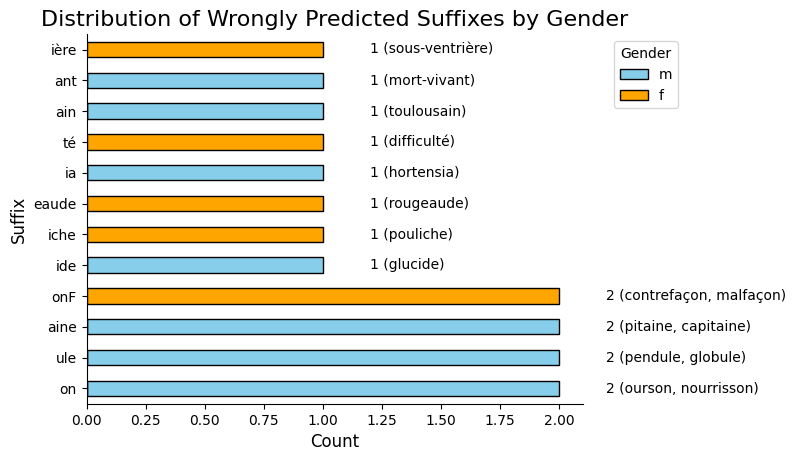

In [20]:
plt.figure(figsize=(18, len(process_distribution) * 0.4))
ax = process_distribution[['m', 'f']].plot(kind='barh', stacked=True, color=['skyblue', 'orange'], edgecolor='black')

plt.title('Distribution of Wrongly Predicted Suffixes by Gender', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Suffix', fontsize=12)
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove top and right spines
sns.despine()

# Add value labels and examples on each segment of the bars
for suffix in process_distribution.index:
    total_width = process_distribution.loc[suffix, 'm'] + process_distribution.loc[suffix, 'f']
    examples = process_distribution.loc[suffix, 'Examples'].split(', ')[:3]
    examples_text = ', '.join(examples)
    ax.text(total_width + 0.2, ax.get_yticks()[list(process_distribution.index).index(suffix)], 
            f'{int(total_width)} ({examples_text})', va='center', ha='left')

plt.show()

### Simplicia

In [21]:
# Look for most common endings (although not suffixes)
simplex_data  = orth_only_error_df[orth_only_error_df['last_process_broad'] == "simplex"][["lemma", "true"]]
lemma_gender = dict(zip(simplex_data['lemma'], simplex_data['true']))
endings = defaultdict(lambda: defaultdict(list))
for lemma, gender in lemma_gender.items():
    endings[lemma[-1]][gender].append(lemma)        # Group by last letter
    if len(lemma) > 1:
        endings[lemma[-2:]][gender].append(lemma)   # Group by last two letters 
    if len(lemma) > 2:
        endings[lemma[-3:]][gender].append(lemma)   # Group by last three letters

print("Most common endings:")
# Note: we print here the true genders
for ending, genders in sorted(endings.items(), key=lambda x: sum(len(v) for v in x[1].values()), reverse=True)[:20]:
    total = sum(len(words) for words in genders.values())
    print(f"\n-{ending}: {total} words")
    for gender, words in genders.items():
        percentage = len(words) / total * 100
        print(f"  {gender}: {len(words)} words ({percentage:.1f}%)")
        words_to_print = words[:20]
        print(f"    {', '.join(words_to_print)}", end="")
        if len(words) > 20:
            print(f" ... and {len(words) - 20} more")
        else:
            print() 


Most common endings:

-e: 30 words
  m: 24 words (80.0%)
    axe, are, jute, mime, site, sexe, morse, orgue, grime, culte, palpe, pagne, cidre, sbire, drive, pence, pulque, baffle, porche, cierge ... and 4 more
  f: 6 words (20.0%)
    gaze, salle, nappe, strate, berthe, bourde

-re: 4 words
  m: 4 words (100.0%)
    are, cidre, sbire, stupre

-te: 4 words
  m: 3 words (75.0%)
    jute, site, culte
  f: 1 words (25.0%)
    strate

-le: 4 words
  f: 1 words (25.0%)
    salle
  m: 3 words (75.0%)
    baffle, couple, braille

-xe: 2 words
  m: 2 words (100.0%)
    axe, sexe

-l: 2 words
  f: 2 words (100.0%)
    girl, gail

-me: 2 words
  m: 2 words (100.0%)
    mime, grime

-ime: 2 words
  m: 2 words (100.0%)
    mime, grime

-se: 2 words
  m: 2 words (100.0%)
    morse, causse

-ue: 2 words
  m: 2 words (100.0%)
    orgue, pulque

-lle: 2 words
  f: 1 words (50.0%)
    salle
  m: 1 words (50.0%)
    braille

-pe: 2 words
  m: 1 words (50.0%)
    palpe
  f: 1 words (50.0%)
    nappe

-he

In [22]:
complex_endings = get_most_complex_endings(endings)

print("Most common endings:")
for ending, genders in sorted(complex_endings.items(), key=lambda x: sum(len(v) for v in x[1].values()), reverse=True)[:20]:
    total = sum(len(words) for words in genders.values())
    print(f"\n-{ending}: {total} words")
    for gender, words in genders.items():
        percentage = len(words) / total * 100
        print(f"  {gender}: {len(words)} words ({percentage:.1f}%)")
        words_to_print = words[:20]
        print(f"    {', '.join(words_to_print)}", end="")
        if len(words) > 20:
            print(f" ... and {len(words) - 20} more")
        else:
            print()


Most common endings:

-ime: 2 words
  m: 2 words (100.0%)
    mime, grime

-lle: 2 words
  f: 1 words (50.0%)
    salle
  m: 1 words (50.0%)
    braille

-axe: 1 words
  m: 1 words (100.0%)
    axe

-bru: 1 words
  f: 1 words (100.0%)
    bru

-clé: 1 words
  f: 1 words (100.0%)
    clé

-are: 1 words
  m: 1 words (100.0%)
    are

-irl: 1 words
  f: 1 words (100.0%)
    girl

-ute: 1 words
  m: 1 words (100.0%)
    jute

-aze: 1 words
  f: 1 words (100.0%)
    gaze

-ite: 1 words
  m: 1 words (100.0%)
    site

-exe: 1 words
  m: 1 words (100.0%)
    sexe

-ail: 1 words
  f: 1 words (100.0%)
    gail

-rse: 1 words
  m: 1 words (100.0%)
    morse

-gue: 1 words
  m: 1 words (100.0%)
    orgue

-lte: 1 words
  m: 1 words (100.0%)
    culte

-lpe: 1 words
  m: 1 words (100.0%)
    palpe

-gne: 1 words
  m: 1 words (100.0%)
    pagne

-dre: 1 words
  m: 1 words (100.0%)
    cidre

-ire: 1 words
  m: 1 words (100.0%)
    sbire

-ive: 1 words
  m: 1 words (100.0%)
    drive


In [23]:
# Analyze gender distribution by word length
length_gender = defaultdict(lambda: defaultdict(int))
for lemma, gender in lemma_gender.items():
    length_gender[len(lemma)][gender] += 1

print("\nWord length and gender distribution:")
for length in sorted(length_gender.keys()):
    total = sum(length_gender[length].values())
    print(f"\n{length} letters: {total} words")
    for gender, count in length_gender[length].items():
        percentage = count / total * 100
        print(f"  {gender}: {count} words ({percentage:.1f}%)")


Word length and gender distribution:

3 letters: 4 words
  m: 2 words (50.0%)
  f: 2 words (50.0%)

4 letters: 7 words
  f: 3 words (42.9%)
  m: 4 words (57.1%)

5 letters: 12 words
  m: 10 words (83.3%)
  f: 2 words (16.7%)

6 letters: 10 words
  m: 7 words (70.0%)
  f: 3 words (30.0%)

7 letters: 1 words
  m: 1 words (100.0%)


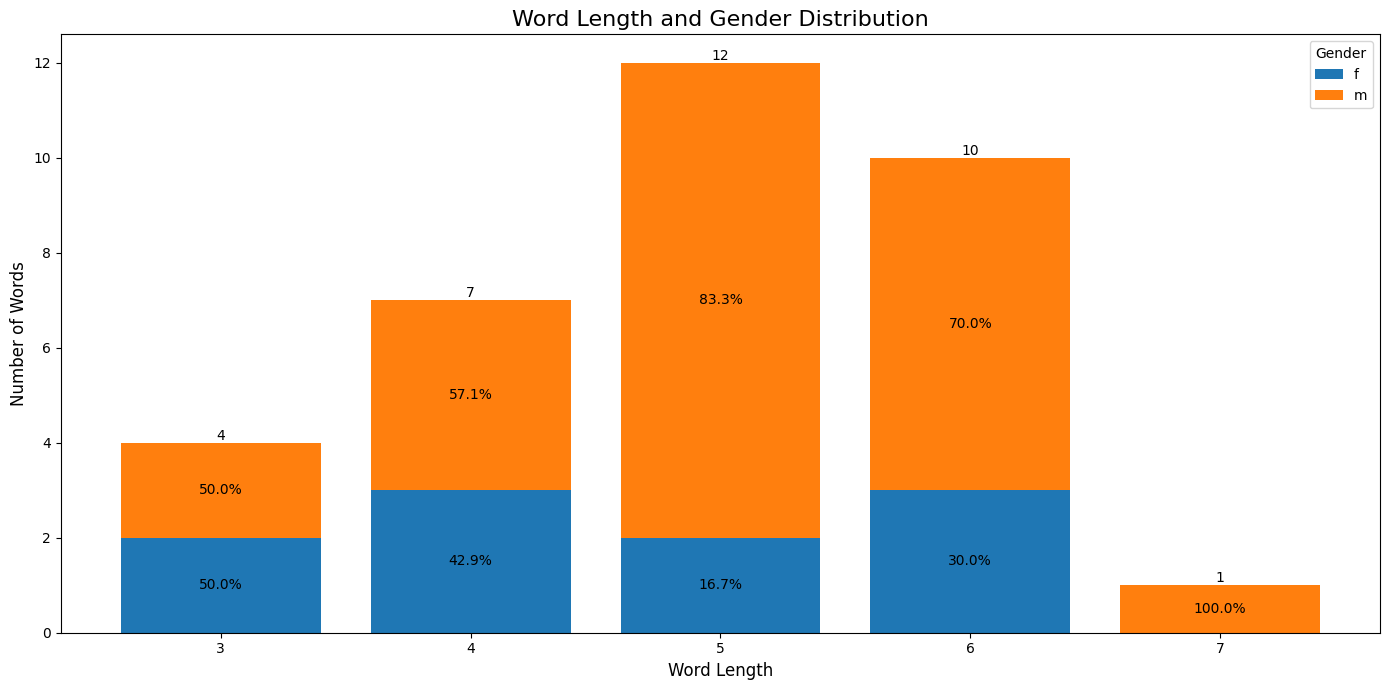

In [24]:
# Plot
lengths = sorted(length_gender.keys())
genders = list(set(gender for length_dict in length_gender.values() for gender in length_dict.keys()))
data = {gender: [length_gender[length].get(gender, 0) for length in lengths] for gender in genders}

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(14, 7))  
bottom = np.zeros(len(lengths))
for gender in genders:
    ax.bar(range(len(lengths)), data[gender], bottom=bottom, label=gender)
    bottom += data[gender]

ax.set_title('Word Length and Gender Distribution', fontsize=16)
ax.set_xlabel('Word Length', fontsize=12)
ax.set_ylabel('Number of Words', fontsize=12)
ax.legend(title='Gender')

# Set x-ticks and labels
ax.set_xticks(range(len(lengths)))
ax.set_xticklabels(lengths)

# Add value labels on the bars
for i, length in enumerate(lengths):
    total = sum(data[gender][i] for gender in genders)
    ax.text(i, total, str(total), ha='center', va='bottom')

# Add percentage labels
for i, length in enumerate(lengths):
    total = sum(data[gender][i] for gender in genders)
    bottom = 0
    for gender in genders:
        count = data[gender][i]
        if count > 0:
            percentage = count / total * 100
            ax.text(i, bottom + count/2, f'{percentage:.1f}%', 
                    ha='center', va='center')
        bottom += count

plt.tight_layout()
plt.show()


## Phonemic only errors
Investigate the lemmas that the phon model got right but the orth model got wrong

In [25]:
phon_only_error_df = model_disagreement_echantinom_df[model_disagreement_echantinom_df['phon_pred'].notna()]
phon_only_error_df.head()

,lemma,phon,orth_pred,true,Class Probabilities,Set,suffix,phon_pred,gen,freq_lex_books,...,autonomous_base,base_stem_phon,sfx_allomorph,der_stem_phon,edit_distance,pattern,pattern_tf,pattern_rel_tf,base_der_sim,offset_sim
166,huppe,yp,NaN,f,"[('y', {'f': 0.15410417318344116, 'm': 0.84589...",test,0,m,f,0.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,onze,2z,NaN,m,"[('2', {'f': 0.002509321318939328, 'm': 0.9974...",test,0,f,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,as,as,NaN,m,"[('a', {'f': 0.45142826437950134, 'm': 0.54857...",test,0,f,m,6.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,pie,pi,NaN,f,"[('p', {'f': 0.4747108519077301, 'm': 0.525289...",test,0,m,f,4.32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,maie,mɛ,NaN,f,"[('m', {'f': 0.04598338156938553, 'm': 0.95401...",test,0,m,f,1.22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Gender distribution of the phon errors
gender_errors = phon_only_error_df['phon_pred'].value_counts()       
gender_percentages = gender_errors / gender_errors.sum() * 100
gender_distribution = pd.DataFrame({
    'Count': gender_errors,
    'Percentage': gender_percentages
})
gender_distribution

,Count,Percentage
phon_pred,,
m,362,60.232945
f,239,39.767055


### Last process broad

In [27]:
# Last process broad distribution
get_category_distribution(phon_only_error_df, "last_process_broad")

,Count,Percentage,Examples
last_process_broad,,,
simplex,132,90.410959,"pli, maque, guêpe, fiel, plie"
conversion,11,7.534247,"gris, mou, vierge, bas, dupe"
nonconcat,3,2.054795,"net, vioque, mac"


In [28]:
phon_only_error_df['last_process_narrow'].value_counts() # We have 16 borrowings, which are:
phon_only_error_df[phon_only_error_df['last_process_narrow'] == 'borrowing']['lemma'].tolist()

['sen',
 'roll',
 'full',
 'par',
 'kit',
 'van',
 'shit',
 'zen',
 'team',
 'green',
 'snack',
 'group',
 'stout',
 'flash',
 'spleen',
 'stress']

### Suffixes

In [29]:
# Suffix distribution
process_distribution = get_category_distribution(phon_only_error_df, "suffix", 'phon')
process_distribution

,Count,Percentage,Examples
suffix,,,
0,508,84.525790,"k2s1tʁe, sɛʁ, 1ʒ1be, ɔʁkide, dəmØʁe"
ette,18,2.995008,"ʒakɛt, fɛʁmɛt, ʃəmizɛt, fʁizɛt, pikɛt"
el,8,1.331115,"3dystʁijɛl, 3dystʁijɛl, kazɥɛl, OmOsEksɥɛl, ʁi..."
is,8,1.331115,"ʁuli, abati, kOlOʁi, tuʁni, vɛʁni"
ée,6,0.998336,"v1tʁe, gule, liɲe, kakte, ane"
al,6,0.998336,"nasjOnal, kOmɛʁsjal, nasjOnal, ʒuʁnal, kOmynal"
ie,4,0.665557,"idjOsi, inɛʁsi, silvi, maladi"
aille,4,0.665557,"pulaj, ʁətʁuvaj, k3kaj, mitʁaj"
onne,3,0.499168,"pOlisɔn, matɔn, mOlasɔn"


In [30]:
# Wrongly predicted suffixes
suffix_gender_counts = phon_only_error_df.groupby(['suffix', 'true']).size().unstack(fill_value=0)

# Merge suffix_gender_counts into process_distribution
process_distribution['m'] = suffix_gender_counts['m']
process_distribution['f'] = suffix_gender_counts['f']
process_distribution = process_distribution.sort_values('Count', ascending=False)
process_distribution = process_distribution[process_distribution.index != '0']
process_distribution

,Count,Percentage,Examples,m,f
suffix,,,,,
ette,18,2.995008,"ʒakɛt, fɛʁmɛt, ʃəmizɛt, fʁizɛt, pikɛt",0,18
el,8,1.331115,"3dystʁijɛl, 3dystʁijɛl, kazɥɛl, OmOsEksɥɛl, ʁi...",8,0
is,8,1.331115,"ʁuli, abati, kOlOʁi, tuʁni, vɛʁni",8,0
ée,6,0.998336,"v1tʁe, gule, liɲe, kakte, ane",0,6
al,6,0.998336,"nasjOnal, kOmɛʁsjal, nasjOnal, ʒuʁnal, kOmynal",6,0
ie,4,0.665557,"idjOsi, inɛʁsi, silvi, maladi",0,4
aille,4,0.665557,"pulaj, ʁətʁuvaj, k3kaj, mitʁaj",0,4
onne,3,0.499168,"pOlisɔn, matɔn, mOlasɔn",0,3
aine,2,0.332779,"k3zɛn, pʁOʃɛn",0,2


<Figure size 1800x1320 with 0 Axes>

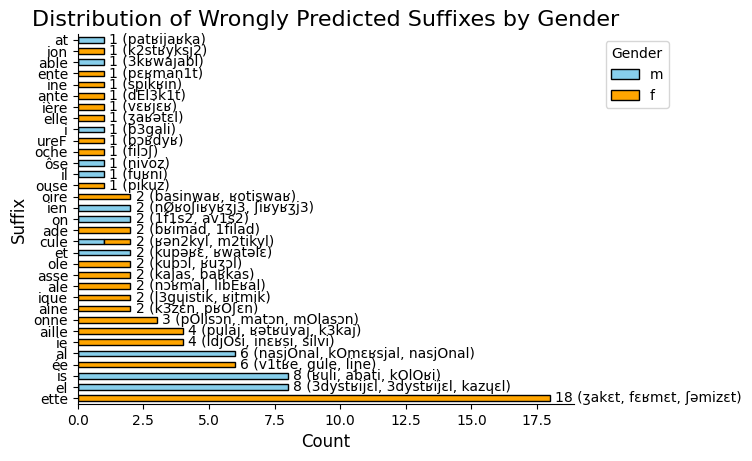

In [31]:
plt.figure(figsize=(18, len(process_distribution) * 0.4))
ax = process_distribution[['m', 'f']].plot(kind='barh', stacked=True, color=['skyblue', 'orange'], edgecolor='black')

plt.title('Distribution of Wrongly Predicted Suffixes by Gender', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Suffix', fontsize=12)
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove top and right spines
sns.despine()

# Add value labels and examples on each segment of the bars
for suffix in process_distribution.index:
    total_width = process_distribution.loc[suffix, 'm'] + process_distribution.loc[suffix, 'f']
    examples = process_distribution.loc[suffix, 'Examples'].split(', ')[:3]
    examples_text = ', '.join(examples)
    ax.text(total_width + 0.2, ax.get_yticks()[list(process_distribution.index).index(suffix)], 
            f'{int(total_width)} ({examples_text})', va='center', ha='left')

plt.show()

### Simplicia

In [34]:
# Look for most common endings (although not suffixes)
simplex_data  = phon_only_error_df[phon_only_error_df['last_process_broad'] == "simplex"][["phon", "true"]]
lemma_gender = dict(zip(simplex_data['phon'], simplex_data['true']))
endings = defaultdict(lambda: defaultdict(list))
for lemma, gender in lemma_gender.items():
    endings[lemma[-1]][gender].append(lemma)        # Group by last letter
    if len(lemma) > 1:
        endings[lemma[-2:]][gender].append(lemma)   # Group by last two letters 
    if len(lemma) > 2:
        endings[lemma[-3:]][gender].append(lemma)   # Group by last three letters

print("Most common endings:")
# Note: we print here the true genders
for ending, genders in sorted(endings.items(), key=lambda x: sum(len(v) for v in x[1].values()), reverse=True)[:20]:
    total = sum(len(words) for words in genders.values())
    print(f"\n-{ending}: {total} words")
    for gender, words in genders.items():
        percentage = len(words) / total * 100
        print(f"  {gender}: {len(words)} words ({percentage:.1f}%)")
        words_to_print = words[:20]
        print(f"    {', '.join(words_to_print)}", end="")
        if len(words) > 20:
            print(f" ... and {len(words) - 20} more")
        else:
            print() 


Most common endings:

-ʁ: 15 words
  f: 12 words (80.0%)
    iʁ, kuʁ, paʁ, baʁ, maʁ, kaʁ, sɛʁ, tɛʁ, spɔʁ, flɔʁ, mwaʁ, fwaʁ
  m: 3 words (20.0%)
    tiʁ, fɛʁ, myʁ

-s: 13 words
  m: 5 words (38.5%)
    as, vis, sas, stʁas, stʁɛs
  f: 8 words (61.5%)
    ʃos, pas, ʁas, ʃas, glis, pwas, gʁas, vals

-l: 13 words
  f: 7 words (53.8%)
    kul, pɛl, mal, kɔl, kal, pal, dwɛl
  m: 6 words (46.2%)
    val, ʁɔl, ful, vɔl, bɛl, fjɛl

-t: 12 words
  f: 6 words (50.0%)
    wat, kot, lat, flɔt, taʁt, kʁɔt
  m: 6 words (50.0%)
    kit, lyt, ʃit, byt, fʁɛt, stut

-p: 9 words
  f: 8 words (88.9%)
    yp, gɛp, top, ʒyp, kap, lup, pup, ʃap
  m: 1 words (11.1%)
    gʁup

-k: 9 words
  f: 7 words (77.8%)
    kɔk, tɔk, lak, mak, plak, klɔk, kʁak
  m: 2 words (22.2%)
    tʁyk, snak

-as: 8 words
  m: 3 words (37.5%)
    as, sas, stʁas
  f: 5 words (62.5%)
    pas, ʁas, ʃas, pwas, gʁas

-m: 8 words
  f: 7 words (87.5%)
    fam, aʁm, ʁim, fɛʁm, bɛʁm, fʁim, flɛm
  m: 1 words (12.5%)
    tim

-n: 7 words
  m: 5 w

In [36]:
complex_endings = get_most_complex_endings(endings)

print("Most common endings:")
for ending, genders in sorted(complex_endings.items(), key=lambda x: sum(len(v) for v in x[1].values()), reverse=True)[:20]:
    total = sum(len(words) for words in genders.values())
    print(f"\n-{ending}: {total} words")
    for gender, words in genders.items():
        percentage = len(words) / total * 100
        print(f"  {gender}: {len(words)} words ({percentage:.1f}%)")
        words_to_print = words[:20]
        print(f"    {', '.join(words_to_print)}", end="")
        if len(words) > 20:
            print(f" ... and {len(words) - 20} more")
        else:
            print()


Most common endings:

-ʁas: 3 words
  f: 2 words (66.7%)
    ʁas, gʁas
  m: 1 words (33.3%)
    stʁas

-lak: 2 words
  f: 2 words (100.0%)
    lak, plak

-ʁim: 2 words
  f: 2 words (100.0%)
    ʁim, fʁim

-ɛʁm: 2 words
  f: 2 words (100.0%)
    fɛʁm, bɛʁm

-waʁ: 2 words
  f: 2 words (100.0%)
    mwaʁ, fwaʁ

-ʁɛʃ: 2 words
  f: 1 words (50.0%)
    kʁɛʃ
  m: 1 words (50.0%)
    pʁɛʃ

-kul: 1 words
  f: 1 words (100.0%)
    kul

-fam: 1 words
  f: 1 words (100.0%)
    fam

-ʃos: 1 words
  f: 1 words (100.0%)
    ʃos

-sɛn: 1 words
  m: 1 words (100.0%)
    sɛn

-gɛp: 1 words
  f: 1 words (100.0%)
    gɛp

-pli: 1 words
  f: 1 words (100.0%)
    pli

-val: 1 words
  m: 1 words (100.0%)
    val

-fig: 1 words
  f: 1 words (100.0%)
    fig

-ʁɔl: 1 words
  m: 1 words (100.0%)
    ʁɔl

-pɛl: 1 words
  f: 1 words (100.0%)
    pɛl

-fiʃ: 1 words
  f: 1 words (100.0%)
    fiʃ

-ʒig: 1 words
  f: 1 words (100.0%)
    ʒig

-kuʁ: 1 words
  f: 1 words (100.0%)
    kuʁ

-top: 1 words
  f: 1 words (100

In [37]:
# Analyze gender distribution by word length
length_gender = defaultdict(lambda: defaultdict(int))
for lemma, gender in lemma_gender.items():
    length_gender[len(lemma)][gender] += 1

print("\nWord length and gender distribution:")
for length in sorted(length_gender.keys()):
    total = sum(length_gender[length].values())
    print(f"\n{length} letters: {total} words")
    for gender, count in length_gender[length].items():
        percentage = count / total * 100
        print(f"  {gender}: {count} words ({percentage:.1f}%)")


Word length and gender distribution:

2 letters: 13 words
  f: 9 words (69.2%)
  m: 4 words (30.8%)

3 letters: 71 words
  f: 50 words (70.4%)
  m: 21 words (29.6%)

4 letters: 35 words
  f: 24 words (68.6%)
  m: 11 words (31.4%)

5 letters: 4 words
  m: 3 words (75.0%)
  f: 1 words (25.0%)


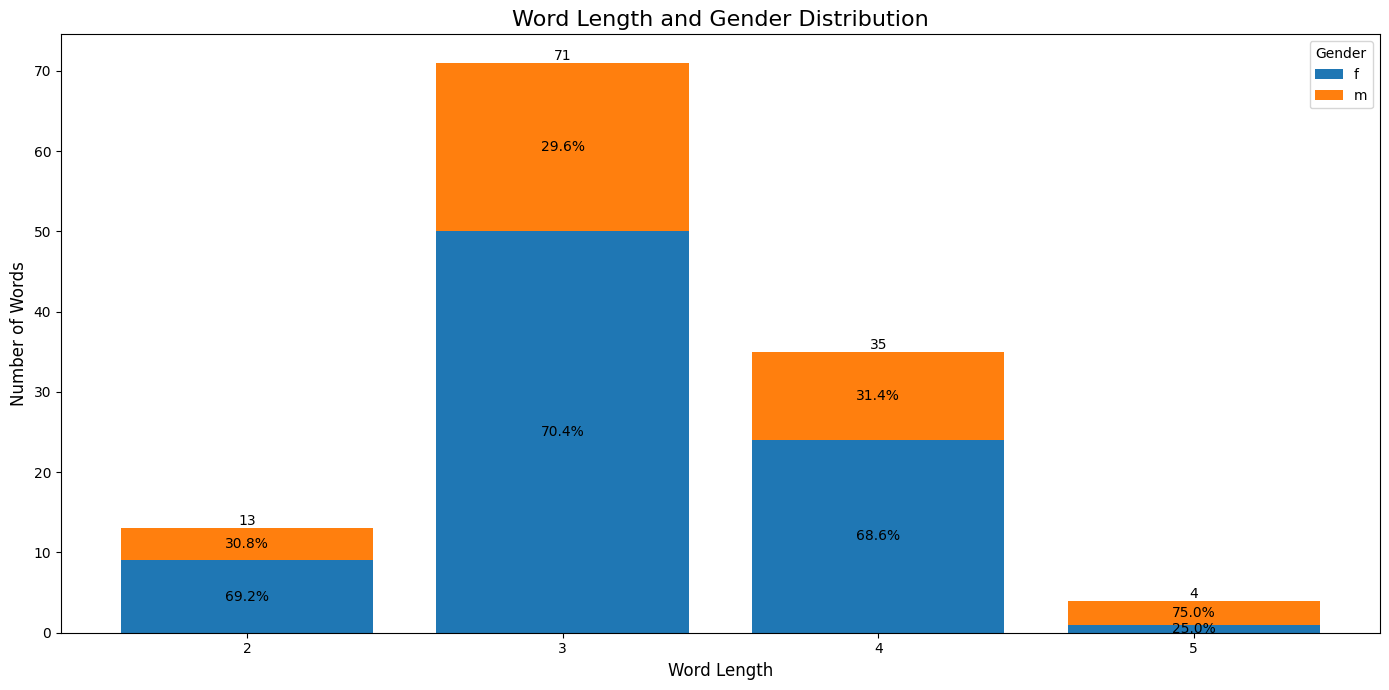

In [38]:
# Plot
lengths = sorted(length_gender.keys())
genders = list(set(gender for length_dict in length_gender.values() for gender in length_dict.keys()))
data = {gender: [length_gender[length].get(gender, 0) for length in lengths] for gender in genders}

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(14, 7))  
bottom = np.zeros(len(lengths))
for gender in genders:
    ax.bar(range(len(lengths)), data[gender], bottom=bottom, label=gender)
    bottom += data[gender]

ax.set_title('Word Length and Gender Distribution', fontsize=16)
ax.set_xlabel('Word Length', fontsize=12)
ax.set_ylabel('Number of Words', fontsize=12)
ax.legend(title='Gender')

# Set x-ticks and labels
ax.set_xticks(range(len(lengths)))
ax.set_xticklabels(lengths)

# Add value labels on the bars
for i, length in enumerate(lengths):
    total = sum(data[gender][i] for gender in genders)
    ax.text(i, total, str(total), ha='center', va='bottom')

# Add percentage labels
for i, length in enumerate(lengths):
    total = sum(data[gender][i] for gender in genders)
    bottom = 0
    for gender in genders:
        count = data[gender][i]
        if count > 0:
            percentage = count / total * 100
            ax.text(i, bottom + count/2, f'{percentage:.1f}%', 
                    ha='center', va='center')
        bottom += count

plt.tight_layout()
plt.show()
